# Results Comparison

Load `results/summary.csv` and compare algorithm performance.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import itertools
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [6]:
from pathlib import Path

results_dir = Path('../results')

# Auto-discover the latest result folder (sorted by name = by timestamp)
run_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir()])
if not run_dirs:
    raise FileNotFoundError(f"No result folders found in {results_dir.resolve()}")

# Use the latest run folder (change index to pick a different one)
run_dir = run_dirs[-1]
print(f"Using run folder: {run_dir.name}")
print(f"Available folders: {[d.name for d in run_dirs]}")

summary_path = next(run_dir.glob("summary_*.csv"), None)
raw_path = next(run_dir.glob("raw_results_*.csv"), None)

if not summary_path:
    raise FileNotFoundError(f"No summary CSV found in {run_dir}")

df = pd.read_csv(summary_path)
print(f"\nSummary: {len(df)} rows, {df['algorithm'].nunique()} algorithms, {df['instance'].nunique()} instances")
print(f"Algorithms: {sorted(df['algorithm'].unique())}")

# Load raw per-run data if available
if raw_path:
    feasible_df = pd.read_csv(raw_path)
    feasible_df = feasible_df[feasible_df['feasible'] == True].copy()
    print(f"Raw results: {len(feasible_df)} feasible runs")
else:
    feasible_df = None
    print("No raw results CSV found")

df.head()

Using run folder: a_20260330_114636
Available folders: ['a_20260330_114248', 'a_20260330_114636']

Summary: 56 rows, 3 algorithms, 20 instances
Algorithms: ['aisle_cluster_expansion', 'simple', 'simple_multi']
Raw results: 56 feasible runs


,dataset,algorithm,instance,total_runs,feasible_runs,timed_out_runs,objective_mean,objective_median,objective_mode,objective_min,objective_max,objective_variance,objective_std_dev,items_mean,items_median,items_mode,items_min,items_max,items_variance,items_std_dev,aisles_mean,aisles_median,aisles_mode,aisles_min,aisles_max,aisles_variance,aisles_std_dev,exec_time_mean,exec_time_median,exec_time_mode,exec_time_min,exec_time_max,exec_time_variance,exec_time_std_dev
0,a,aisle_cluster_expansion,instance_0001.txt,1,1,0,12.500000,12.500000,12.500000,12.500000,12.500000,0.0,0.0,50.0,50.0,50,50,50,0.0,0.0,4.0,4.0,4,4,4,0.0,0.0,0.022605,0.022605,0.022605,0.022605,0.022605,0.0,0.0
1,a,aisle_cluster_expansion,instance_0002.txt,1,1,0,2.000000,2.000000,2.000000,2.000000,2.000000,0.0,0.0,2.0,2.0,2,2,2,0.0,0.0,1.0,1.0,1,1,1,0.0,0.0,0.000360,0.000360,0.000360,0.000360,0.000360,0.0,0.0
2,a,aisle_cluster_expansion,instance_0003.txt,1,1,0,8.500000,8.500000,8.500000,8.500000,8.500000,0.0,0.0,34.0,34.0,34,34,34,0.0,0.0,4.0,4.0,4,4,4,0.0,0.0,0.040395,0.040395,0.040395,0.040395,0.040395,0.0,0.0
3,a,aisle_cluster_expansion,instance_0004.txt,1,1,0,3.500000,3.500000,3.500000,3.500000,3.500000,0.0,0.0,7.0,7.0,7,7,7,0.0,0.0,2.0,2.0,2,2,2,0.0,0.0,0.004328,0.004328,0.004328,0.004328,0.004328,0.0,0.0
4,a,aisle_cluster_expansion,instance_0005.txt,1,1,0,138.090909,138.090909,138.090909,138.090909,138.090909,0.0,0.0,1519.0,1519.0,1519,1519,1519,0.0,0.0,11.0,11.0,11,11,11,0.0,0.0,1.639655,1.639655,1.639655,1.639655,1.639655,0.0,0.0


## Summary Table: mean ± std of objective and time per (algorithm, instance)

In [7]:
if feasible_df is not None:
    summary = feasible_df.groupby(['algorithm', 'instance']).agg(
        obj_mean=('objective', 'mean'),
        obj_std=('objective', 'std'),
        time_mean=('time_s', 'mean'),
        time_std=('time_s', 'std'),
        feasible_runs=('feasible', 'count'),
    ).round(4)

    summary['objective'] = summary.apply(
        lambda r: f"{r['obj_mean']:.4f} ± {r['obj_std']:.4f}" if pd.notna(r['obj_std']) else f"{r['obj_mean']:.4f}",
        axis=1
    )
    summary['time_s'] = summary.apply(
        lambda r: f"{r['time_mean']:.4f} ± {r['time_std']:.4f}" if pd.notna(r['time_std']) else f"{r['time_mean']:.4f}",
        axis=1
    )

    summary[['objective', 'time_s', 'feasible_runs']]
else:
    print("No raw results available — skipping per-run summary.")

## Boxplot: Objective Distribution per Algorithm

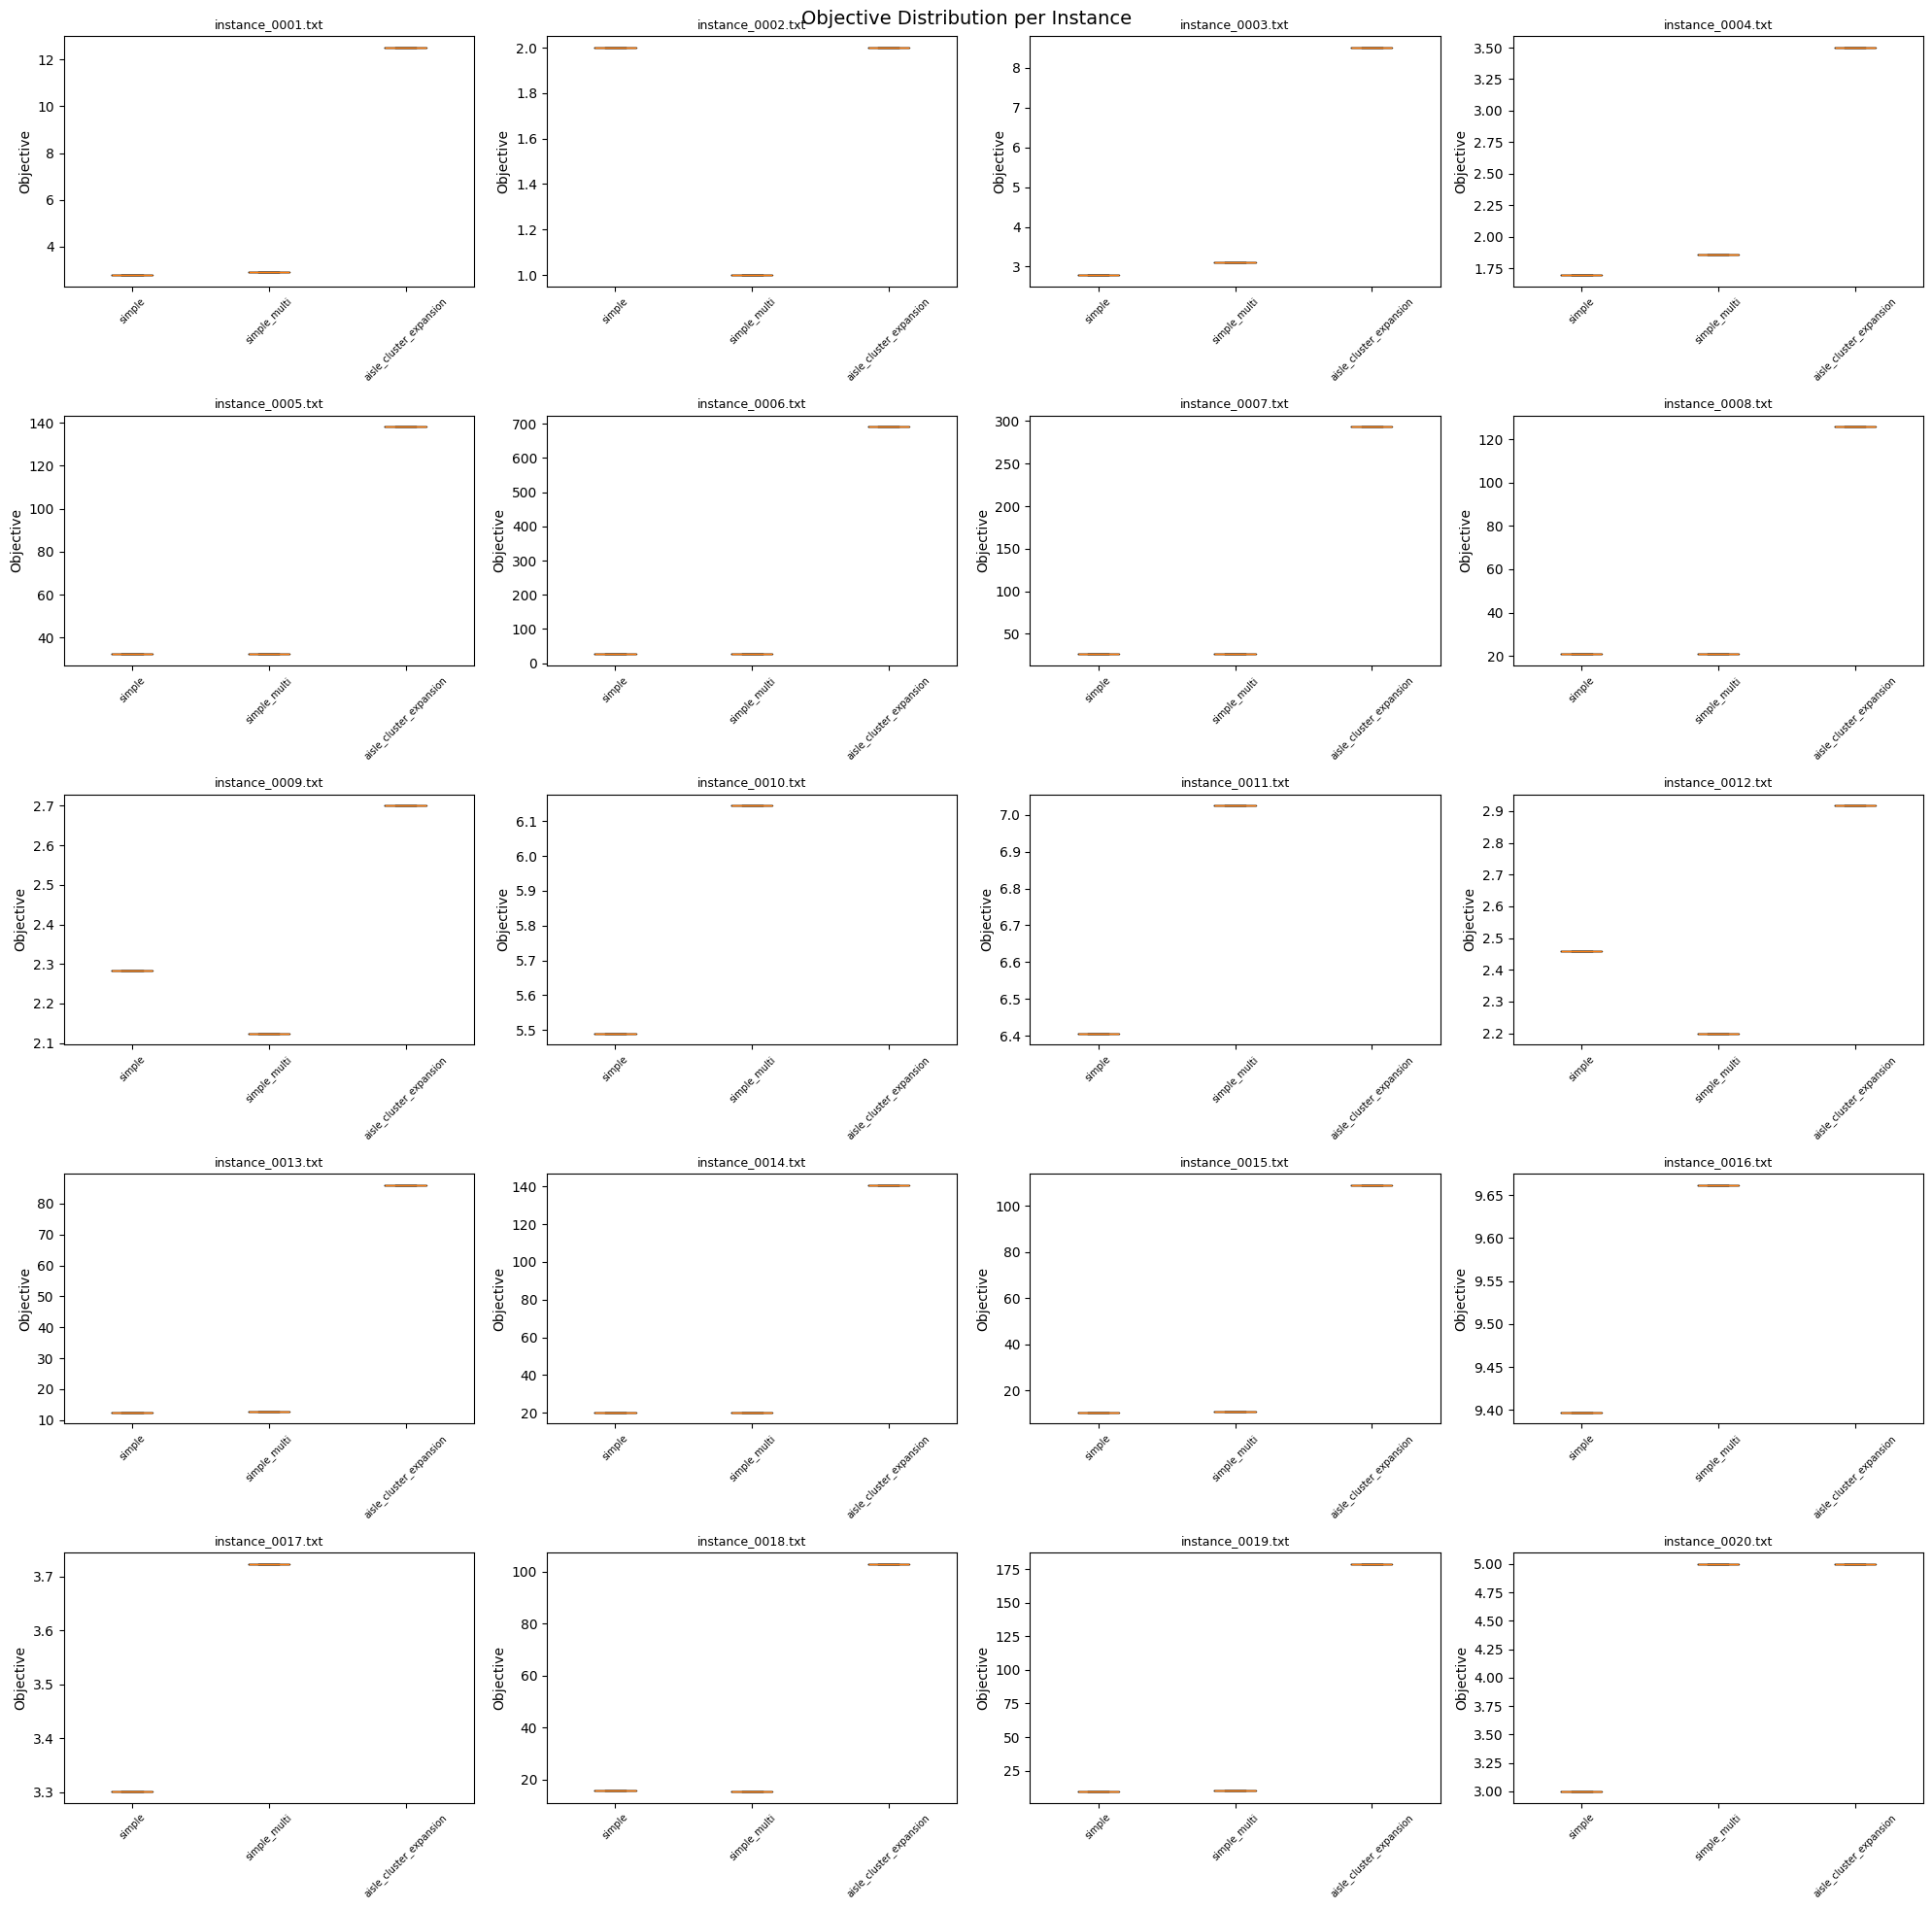

In [8]:
if feasible_df is not None:
    algorithms = feasible_df['algorithm'].unique()
    instances = sorted(feasible_df['instance'].unique())

    if len(algorithms) > 0:
        n_instances = len(instances)
        n_cols = min(4, n_instances)
        n_rows = (n_instances + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

        for idx, instance in enumerate(instances):
            ax = axes[idx // n_cols][idx % n_cols]
            data = [feasible_df[(feasible_df['instance'] == instance) & (feasible_df['algorithm'] == algo)]['objective'].values
                    for algo in algorithms]
            ax.boxplot(data, labels=algorithms, vert=True)
            ax.set_title(instance, fontsize=9)
            ax.set_ylabel('Objective')
            ax.tick_params(axis='x', rotation=45, labelsize=7)

        for idx in range(len(instances), n_rows * n_cols):
            axes[idx // n_cols][idx % n_cols].set_visible(False)

        plt.suptitle('Objective Distribution per Instance', fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print("No raw results available — skipping boxplot.")

## Aggregate Boxplot: Objective per Algorithm (all instances)

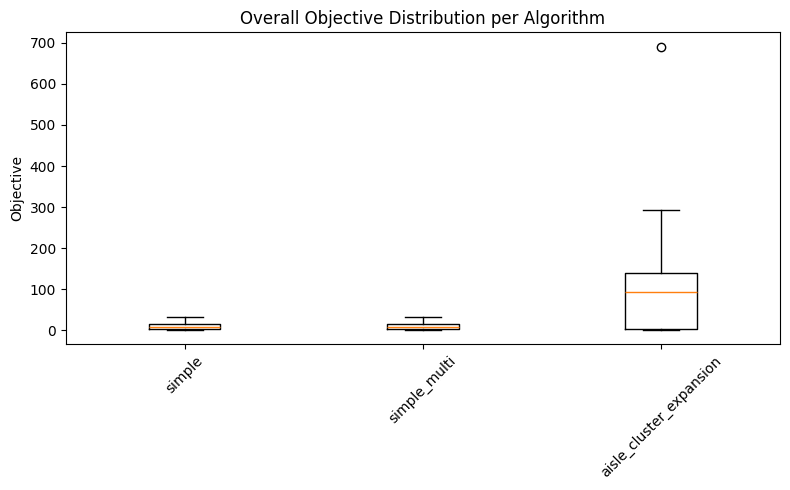

In [9]:
if feasible_df is not None and len(algorithms) > 1:
    fig, ax = plt.subplots(figsize=(max(8, len(algorithms) * 1.5), 5))
    data = [feasible_df[feasible_df['algorithm'] == algo]['objective'].values for algo in algorithms]
    ax.boxplot(data, labels=algorithms, vert=True)
    ax.set_ylabel('Objective')
    ax.set_title('Overall Objective Distribution per Algorithm')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## Statistical Test: Pairwise Wilcoxon Signed-Rank Test

In [10]:
if feasible_df is not None and len(algorithms) > 1:
    pivot = feasible_df.groupby(['algorithm', 'instance'])['objective'].mean().unstack(level=0)

    pairs = list(itertools.combinations(algorithms, 2))
    results_stat = []

    for algo_a, algo_b in pairs:
        if algo_a not in pivot.columns or algo_b not in pivot.columns:
            continue

        common = pivot[[algo_a, algo_b]].dropna()
        if len(common) < 5:
            results_stat.append({'A': algo_a, 'B': algo_b, 'statistic': None, 'p_value': None, 'n': len(common)})
            continue

        try:
            stat_result = stats.wilcoxon(common[algo_a], common[algo_b], alternative='two-sided')
            results_stat.append({
                'A': algo_a, 'B': algo_b,
                'statistic': stat_result.statistic,
                'p_value': stat_result.pvalue,
                'n': len(common),
                'significant_005': stat_result.pvalue < 0.05,
            })
        except ValueError:
            results_stat.append({'A': algo_a, 'B': algo_b, 'statistic': None, 'p_value': None, 'n': len(common)})

    if results_stat:
        pd.DataFrame(results_stat)
    else:
        print('Not enough data for statistical tests.')

## Execution Time Comparison

In [11]:
if feasible_df is not None:
    time_summary = feasible_df.groupby('algorithm')['time_s'].agg(['mean', 'std', 'min', 'max']).round(4)
    time_summary